# CS 171 Final Project — Data Pre-processing & Model Construction  
## Predicting Diabetes Risk using the [Pima Indians Dataset](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)
**Author:** Ryan Tran

This notebook covers **the two required stages** of the project:

1. **Data Preparation**  
   - Load and inspect the Pima Indians Diabetes dataset  
   - Identify physiologically impossible zero values in key medical measurements  
   - Convert those zeros to missing values (`NaN`) and impute them  
   - Split the data into training and test sets while avoiding data leakage  

2. **Model Construction (Random Forest)**  
   - Define a Random Forest classifier
   - Use `GridSearchCV` with stratified cross-validation to tune hyperparameters  
   - Train the best model and evaluate it on the held-out test set  

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split

## Start by visualizing how our dataset looks like:

In [2]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Inspecting the raw dataset

I check the shape, data types, and summary statistics of the dataset.
This tells me how many samples and features I have, and whether any obvious type
issues or extreme values appear.

In [3]:
print("Shape:", df.shape)
df.info()

# Summary statistics
df.describe()

Shape: (768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Outcome distribution (class balance)

The target variable `Outcome` indicates diabetes (1) vs. no diabetes (0).
Before cleaning, I want to see how balanced the classes are.

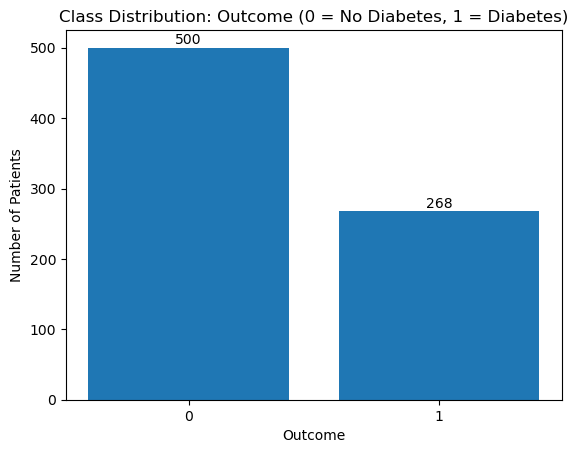

Outcome
0    500
1    268
Name: count, dtype: int64

In [4]:
outcome_counts = df["Outcome"].value_counts().sort_index()

plt.figure()
plt.bar(outcome_counts.index.astype(str), outcome_counts.values)
plt.title("Class Distribution: Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")
for x, y in zip(outcome_counts.index.astype(str), outcome_counts.values):
    plt.text(x, y + 5, str(y), ha="center")
plt.show()

outcome_counts


### Feature distributions (before cleaning)

I visualize the distribution of each feature. This helps reveal skew, outliers, and suspicious spikes at 0 that may correspond to missing or impossible values.

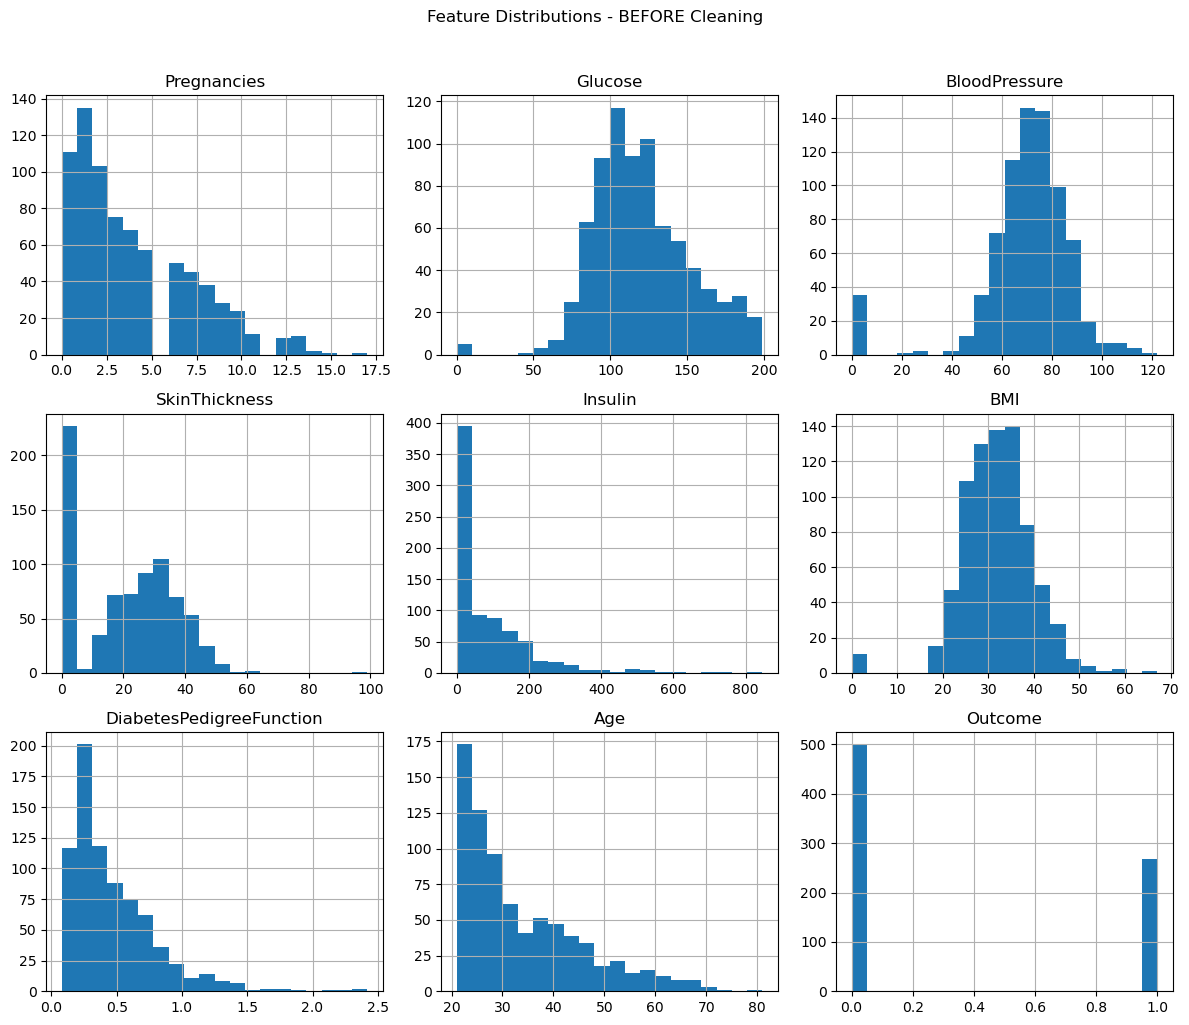

In [5]:
#Visualize raw distributions ( BEFORE cleaning )
df.hist(figsize=(12, 10), bins=20)
plt.suptitle("Feature Distributions - BEFORE Cleaning", y=1.02)
plt.tight_layout()
plt.show()

## Identifying impossible zero values

From our observations, the dataset seems to put missing measurements **as 0**
for several medical features. However, for measurements like glucose, insulin,
blood pressure, skin thickness, and BMI, an actual value of 0 is
**physiologically** impossible afor a living patient.

Therefore, I count how many zeros appear in each column and visualize them.

Zero counts per column:
 Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


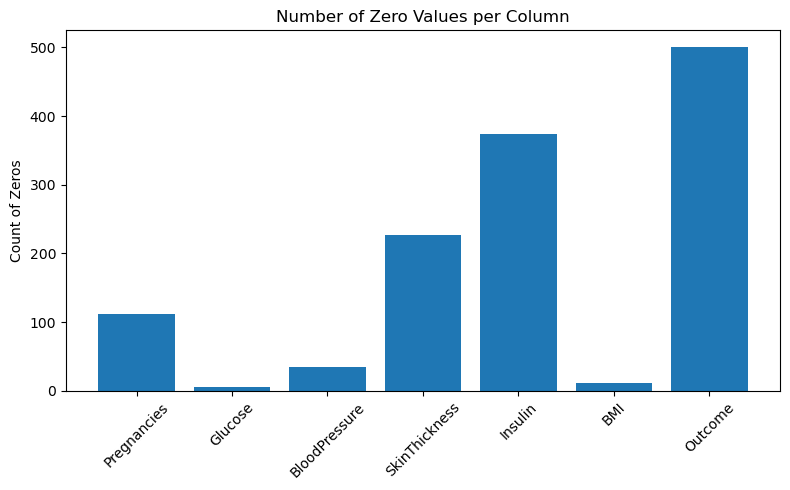

In [6]:
zero_counts = (df == 0).sum()
print("Zero counts per column:\n", zero_counts)
non_zero_cols = zero_counts[zero_counts > 0]

plt.figure(figsize=(8, 5))
plt.bar(non_zero_cols.index, non_zero_cols.values)
plt.title("Number of Zero Values per Column")
plt.ylabel("Count of Zeros")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

We see that:

- `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` all contain zeros.
- For example, `Insulin` has 374 zeros and `SkinThickness` has 227 zeros.

I'll treat zeros in these columns as missing data. 0 is not a valid measurement, and I'll convert those
zeros to `NaN`


In [7]:
columns_with_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace zeros with NaN
df_clean = df.copy()
df_clean[columns_with_missing] = df_clean[columns_with_missing].replace(0, np.nan)

# Show missing counts
print("\nMissing values per column AFTER converting zeros to NaN:")
print(df_clean.isna().sum())


Missing values per column AFTER converting zeros to NaN:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


## Train–test split **before** imputation (avoiding data leakage)

To evaluate the model fairly, I need a held-out set that emulates **new,
unseen patients**. Any preprocessing that uses information from *all* rows
(such as computing medians) could accidentally leak information from the test
set into the training process.

To avoid this, I:

1. Split the data into training and test sets.
2. Compute imputation values (medians) **only on the training set**.
3. Apply those training medians to both train and test features.

This prevents **data leakage** so that the test set remains unseen.


In [8]:
X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y 
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nMissing values in X_train BEFORE imputation:")
print(X_train.isna().sum())

print("\nMissing values in X_test BEFORE imputation:")
print(X_test.isna().sum())

X_train shape: (614, 8)
X_test shape: (154, 8)

Missing values in X_train BEFORE imputation:
Pregnancies                   0
Glucose                       4
BloodPressure                23
SkinThickness               175
Insulin                     290
BMI                           9
DiabetesPedigreeFunction      0
Age                           0
dtype: int64

Missing values in X_test BEFORE imputation:
Pregnancies                  0
Glucose                      1
BloodPressure               12
SkinThickness               52
Insulin                     84
BMI                          2
DiabetesPedigreeFunction     0
Age                          0
dtype: int64


## Imputing missing values with training medians

For the features with missing values, I use **median imputation**:

[https://www.geeksforgeeks.org/machine-learning/what-is-data-imputation/]


- The **median** is robust to outliers
- It maintains the general location of the distribution without being affected by the extreme values.
- Using the **training set medians** keeps the test set independent.

I then fill NaNs in both `X_train` and `X_test` using the training medians.


In [9]:
X_train = X_train.copy()
X_test = X_test.copy()

median_values = X_train[columns_with_missing].median()
print("\nTraining set medians used for imputation:")
print(median_values)

# Fill NaNs in both train and test using training medians
X_train.loc[:, columns_with_missing] = X_train[columns_with_missing].fillna(median_values)
X_test.loc[:, columns_with_missing] = X_test[columns_with_missing].fillna(median_values)

print("\nMissing values in X_train after imputation:")
print(X_train.isna().sum())

print("\nMissing values in X_test after imputation:")
print(X_test.isna().sum())


Training set medians used for imputation:
Glucose          117.0
BloodPressure     72.0
SkinThickness     29.0
Insulin          125.0
BMI               32.4
dtype: float64

Missing values in X_train after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64

Missing values in X_test after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


## Visualizing distributions before vs. after cleaning

To verify that cleaning did not completely distort the data, I compare the
distributions of a few key features (`Glucose`, `BloodPressure`, `BMI`) before
cleaning (raw `df`) and after imputation (`X_train`).

I expect:

- The spike at 0 to disappear.
- The overall shape of the distribution to remain similar, but without impossible values.


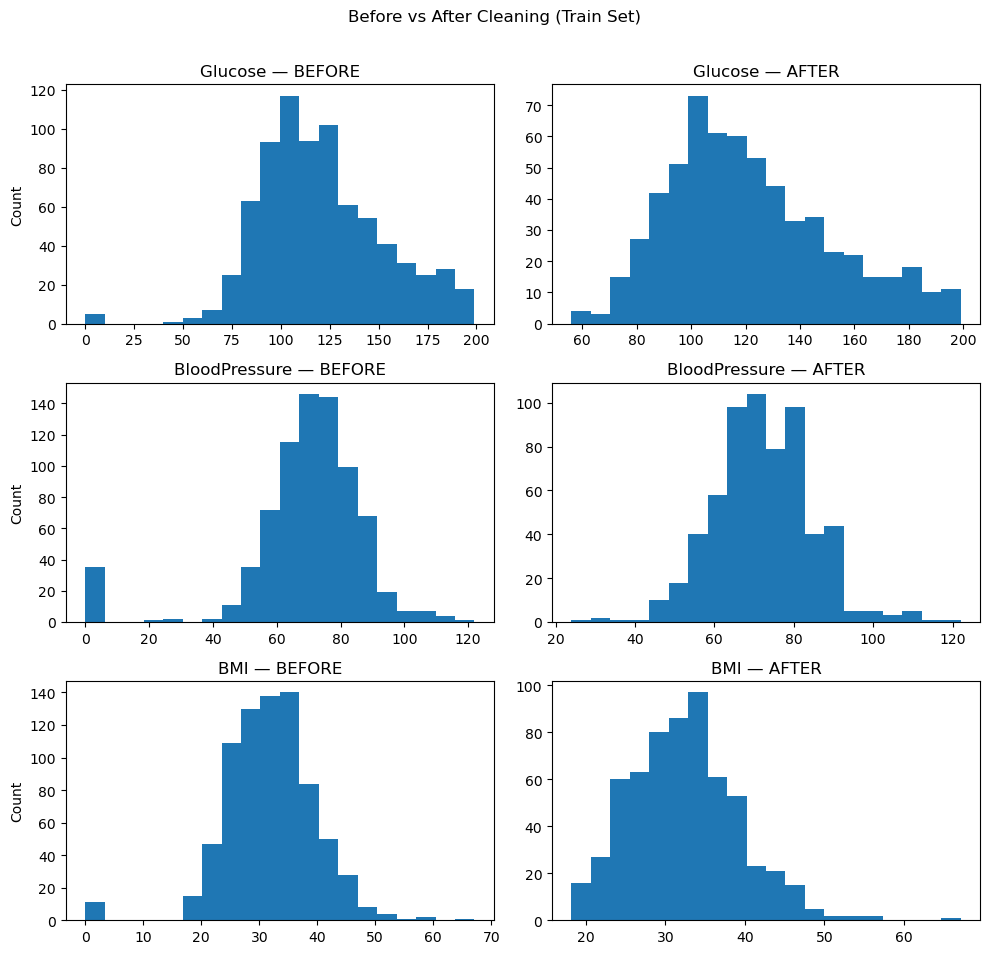

In [10]:
features_to_compare = ["Glucose", "BloodPressure", "BMI"]

fig, axes = plt.subplots(len(features_to_compare), 2, figsize=(10, 10))
fig.suptitle("Before vs After Cleaning (Train Set)", y=0.95)

for i, col in enumerate(features_to_compare):
    # Before cleaning (raw data)
    axes[i, 0].hist(df[col], bins=20)
    axes[i, 0].set_title(f"{col} — BEFORE")
    axes[i, 0].set_ylabel("Count")

    # After cleaning (train set)
    axes[i, 1].hist(X_train[col], bins=20)
    axes[i, 1].set_title(f"{col} — AFTER")
    
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


Visually, the cleaned features:

- No longer contain impossible zeros.
- Preserve realistic ranges and shapes.
- Are ready for scaling and model training in the separate **model notebook**.


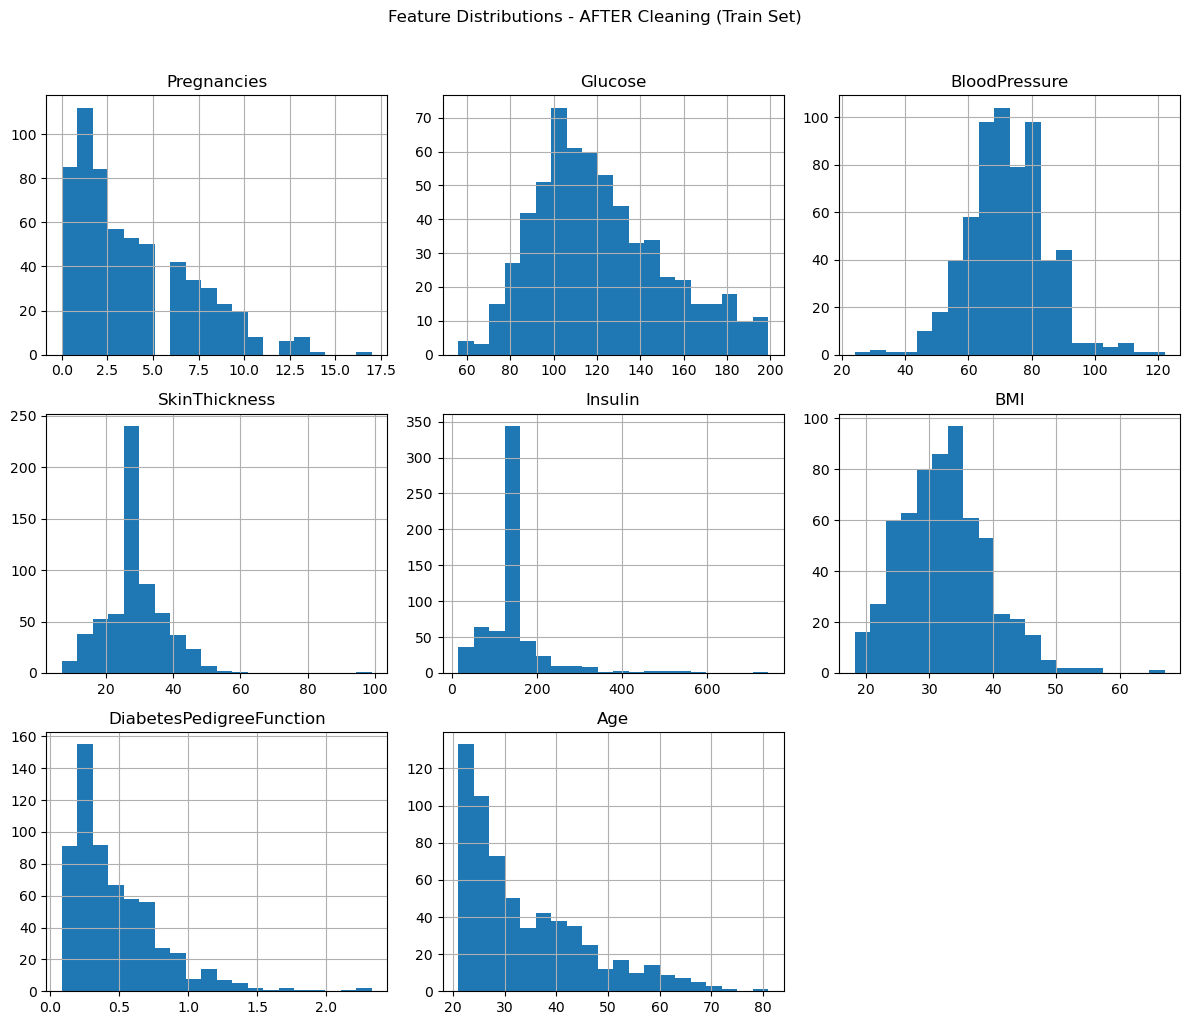

In [11]:
X_train_for_plot = X_train.copy()

X_train_for_plot.hist(figsize=(12, 10), bins=20)
plt.suptitle("Feature Distributions - AFTER Cleaning (Train Set)", y=1.02)
plt.tight_layout()
plt.show()

## Model Construction — Random Forest Classifier

For this project, I chose a **Random Forest** classifier as my main model because:

- It can capture **non-linear interactions** between features.
- Handles mixed feature scales
- It provides built-in measures of feature importance.
- Using `class_weight="balanced"` helps account for the moderate class imbalance
  between Outcome 0 and 1.

I use **GridSearchCV** with **stratified 5-fold cross-validation** to tune:

- Number of trees (`n_estimators`)
- Maximum tree depth (`max_depth`)
- Minimum samples required to split and to be a leaf
- Number of features considered at each split (`max_features`)

The hyperparameter search is optimized for **ROC AUC**, which (as covered in class!) summarizes the
trade-off between true positive rate and false positive rate. 


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay,
    ConfusionMatrixDisplay
)

In [16]:
print("Training label distribution:")
print(y_train.value_counts(normalize=True))
print("\nTest label distribution:")
print(y_test.value_counts(normalize=True))


Training label distribution:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Test label distribution:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


In [17]:
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"  # helps with class imbalance
)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 4, 6, 8],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="roc_auc",   # optimize for ROC AUC
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\nBest hyperparameters found:")
print(grid_search.best_params_)

print(f"\nBest cross-validated ROC AUC (train CV): {grid_search.best_score_:.3f}")


Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Best hyperparameters found:
{'max_depth': 4, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

Best cross-validated ROC AUC (train CV): 0.842


## Final Model and Test Set Evaluation

After hyperparameter tuning, I use the best Random Forest model and evaluate it on the held-out test set.

For metrics, I use:

- Accuracy
- Precision
- Recall
- F1-score
- ROC AUC

These metrics show how well the model distinguishes between patients with
and without diabetes on unseen data.


In [18]:
best_rf = grid_search.best_estimator_
print("\nBest Random Forest model:")
print(best_rf)

# Predictions on test set
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

# Metrics
test_accuracy  = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall    = recall_score(y_test, y_pred)
test_f1        = f1_score(y_test, y_pred)
test_roc_auc   = roc_auc_score(y_test, y_proba)

print("\nTest Set Performance (Best Random Forest):")
print(f"Accuracy:  {test_accuracy:.3f}")
print(f"Precision: {test_precision:.3f}")
print(f"Recall:    {test_recall:.3f}")
print(f"F1-score:  {test_f1:.3f}")
print(f"ROC AUC:   {test_roc_auc:.3f}")



Best Random Forest model:
RandomForestClassifier(class_weight='balanced', max_depth=4,
                       max_features='log2', min_samples_split=5,
                       n_estimators=200, n_jobs=-1, random_state=42)

Test Set Performance (Best Random Forest):
Accuracy:  0.753
Precision: 0.621
Recall:    0.759
F1-score:  0.683
ROC AUC:   0.816


## Saving model and dataset

In [21]:
import os
import joblib

# Save cleaned splits for use in the visualization notebook
os.makedirs("processed", exist_ok=True)

X_train.to_csv("processed/X_train_clean.csv", index=False)
X_test.to_csv("processed/X_test_clean.csv", index=False)
y_train.to_csv("processed/y_train_clean.csv", index=False)
y_test.to_csv("processed/y_test_clean.csv", index=False)

print("Saved cleaned train/test splits in 'processed/'")

#  Save the trained Random Forest model
os.makedirs("models", exist_ok=True)
joblib.dump(best_rf, "models/best_random_forest.pkl")

print("Saved trained Random Forest model to 'models/best_random_forest.pkl'")


Saved cleaned train/test splits in 'processed/'
Saved trained Random Forest model to 'models/best_random_forest.pkl'
